In [1]:
import matplotlib.pyplot as plt
import numpy as np
import arc
import pairinteraction as pi
if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=False)
import os
from IPython.display import Latex
import scipy
import pandas as pd
from pandas import DataFrame
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
h = scipy.constants.h
epsilon_0 = scipy.constants.epsilon_0
a_0 = scipy.constants.physical_constants['Bohr radius']
e = scipy.constants.e

KeyboardInterrupt: 

In [ ]:
from pairinteraction.visualization.colormaps import alphamagma
import os
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 2, 2
l1_1, l2_1 = 1, 3
j1_0, j2_0 = 5/2, 5/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()  


n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
    

In [3]:
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)
channel=0

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  \
0           3    55     2   2.5    63     2   2.5    56     1   1.5    61   
1           2    55     2   2.5    53     2   2.5    57     1   1.5    50   
2           4    55     2   2.5    63     2   2.5    56     1   1.5    61   
3           1    69     2   2.5    66     2   2.5    71     1   1.5    63   
4           0    69     2   2.5    66     2   2.5    71     1   1.5    63   

   l2_1  j2_1  dif  change1  change2     defect       c3k  
0     3   2.5    8        1       -2  12.463118 -2.244110  
1     3   3.5   -2        2       -3  18.490508 -2.732580  
2     3   3.5    8        1       -2   8.839400 -8.691399  
3     3   3.5   -3        2       -3  -7.695556 -6.949672  
4     3   2.5   -3        2       -3  -4.409619 -1.794398  


In [ ]:
from pairinteraction.visualization.colormaps import alphamagma
import os
channels_locs = np.arange(channel, len(channels))
for channel in channels_locs:
    c = channels.loc[channel]
    # set atom properties
    n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
    n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
    mj1, mj2 = j1_0, j2_0
    f1_0, f2_0 = 1, 1

    n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
    n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
    mj1_1, mj2_1 = j1_1, j2_1
    f1_1, f2_1 = 1, 1

    ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
    ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
    ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
    ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)

    defect = ket1_1.get_energy(energy_unit) + ket2_1.get_energy(energy_unit) - ket1.get_energy(energy_unit) - ket2.get_energy(energy_unit)

    # approx b field
    gj1_0, gj2_0 = arc_atom1.getLandegj(l1_0, j1_0, s=1/2), arc_atom2.getLandegj(l2_0, j2_0, s=1/2)
    gj1_1, gj2_1 = arc_atom1.getLandegj(l1_1, j1_1, s=1/2), arc_atom2.getLandegj(l2_1, j2_1, s=1/2)

    shift0 = mj1 * gj1_0 * scipy.constants.physical_constants['Bohr magneton'][0] + mj2 * gj2_0 * scipy.constants.physical_constants['Bohr magneton'][0]
    shift1 = mj1_1 * gj1_1 * scipy.constants.physical_constants['Bohr magneton'][0] + mj2_1 * gj2_1 * scipy.constants.physical_constants['Bohr magneton'][0]

    b = defect / (shift0 - shift1)*h*1e6*1e4

    print(f'b {b}')
    maxb = abs(3*b)
    minb = 0
    num=500
    magnetic_fields = np.linspace(minb,maxb,num)
    n_dif = 3
    jdif = 3
    ldif = 3
    e=0
    energy_unit = 'MHz'

    figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\Magnetic Plots\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\'

    datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\Zeeman tunes\\{atom1}{atom2}\\{orbs[l1_0]}{orbs[l2_0]}\\to {orbs[l1_1]}{orbs[l2_1]}\\j1j2({j1_0},{j2_0})\\'

    if not os.path.exists(datapath):
        os.makedirs(datapath)

    if not os.path.exists(figpath):
        os.makedirs(figpath)

    n1=n1_0
    n2=n2_0

    ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))
    ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

    ket1_energy = ket1.get_energy(unit=energy_unit)
    ket2_energy = ket2.get_energy(unit=energy_unit)

    basis1 = pi.BasisAtom(
        atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))
    basis2 = pi.BasisAtom(
        atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+2), j=(1/2,ket2.j+1), m=(-ket2.j-1,ket2.j+1))

    ket1systems = [
        pi.SystemAtom(ket1basis).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm") for b in magnetic_fields]
    ket2systems = [
        pi.SystemAtom(ket2basis).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm") for b in magnetic_fields]
    

    systems1 = [
        pi.SystemAtom(basis1).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, e], unit="V/cm").set_diamagnetism_enabled(True) for b in magnetic_fields]
    systems2 = [
        pi.SystemAtom(basis2).set_magnetic_field([0, 0, b], unit='G').set_electric_field([0, 0, -e], unit="V/cm").set_diamagnetism_enabled(True) for b in magnetic_fields]

    pi.diagonalize(
        ket1systems, diagonalizer="eigen", sort_by_energy=True)
    pi.diagonalize(
        ket2systems, diagonalizer="eigen", sort_by_energy=True)

    ket1energies = [system.get_eigenenergies(unit=energy_unit) - ket1_energy for system in ket1systems]
    ket2energies = [system.get_eigenenergies(unit=energy_unit) - ket2_energy for system in ket2systems]

    pi.diagonalize(
        systems1, diagonalizer="eigen", sort_by_energy=True)
    pi.diagonalize(
        systems2, diagonalizer="eigen", sort_by_energy=True)
    
    eigenenergies1 = [system.get_eigenenergies(unit=energy_unit) - ket1_energy for system in systems1] 
    eigenenergies2 = [system.get_eigenenergies(unit=energy_unit) - ket2_energy for system in systems2]

    overlaps1 = [system.get_eigenbasis().get_overlaps(ket1) for system in systems1]
    overlaps2 = [system.get_eigenbasis().get_overlaps(ket2) for system in systems2]

    fig = plt.figure(figsize = (8,5))
    energy_lim = abs(defect + defect)
    eigenenergies_pair = []
    state0s = []

    for i, channel1 in enumerate(np.transpose(eigenenergies1)):
        for j, channel2 in enumerate(np.transpose(eigenenergies2)):
            eigenenergy = channel1 + channel2
            if abs(channel1[0]) <= abs(ket1_1.get_energy(energy_unit)-ket1_energy)+2 and abs(channel1[0]) <= abs(ket1_1.get_energy(energy_unit)-ket1_energy)+2:
                plt.plot(magnetic_fields, eigenenergy, c=".1", lw=0.25)
                

                eigenenergies_pair.append(eigenenergy)
                if  eigenenergy[0] == 0:
                    state0s.append(eigenenergy)
                    # print(state0[-1])
    offset=defect/2
    min_energy = -energy_lim+offset
    max_energy = energy_lim+offset
    plt.title(f'{str(ket1)}{str(ket2)}')
    plt.ylim(min_energy, max_energy)
    plt.ylabel(f"Energy [{energy_unit}]")
    plt.xlabel("Magnetic Field [G]")

    tunes=[]
    for eigenenergy in eigenenergies_pair:
        if eigenenergy[0] == state0s[0][0]:
            continue
        elif round(defect, 3)-.5 <= round(eigenenergy[0],2) <= round(defect, 3)+.5:

            for state0 in state0s:
                
                energy = eigenenergy-state0
                cross = min(energy, key=abs)
                if abs(cross) < 1:
                    index = list(energy).index(cross)
                    if index == 0 or index == len(magnetic_fields)-1:
                        continue
                    else:
                        tuned = magnetic_fields[index]
                        plt.vlines(x=tuned, ymin = min_energy, ymax = eigenenergy[index], linestyles='dashed', colors='magenta', linewidth = 0.5)
                        tunes.append(tuned)

    plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')
    print(set(tunes))
    # tunes = np.array(set(tunes))
    print(type(tunes))
    tunes = pd.DataFrame({'tunes' : tunes})

    tunes.to_csv(datapath + f'{n1_0}{n2_0}.csv')
    fig.savefig(figpath + f'{n1_0}{n2_0}.png')
    fig.show()
    plt.close()
    print(channel)

    

b 4.794792829374241


KeyboardInterrupt: 

Text(0.5, 0.98, 'basis: n$\\pm$3, j = (1/2, j + 3), m = (-(j+3), j+3)\nl=(0, 3), B = infG')

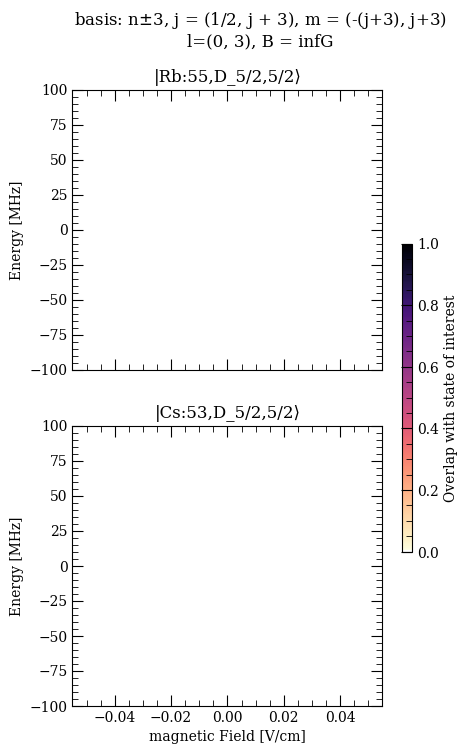

In [5]:

fig, ax = plt.subplots(2,1, sharex=True, figsize=(5,8))
ylim = 100
ax[0].set_ylabel(f"Energy [{energy_unit}]")

ax[0].plot(magnetic_fields, np.array(eigenenergies1), c=".1", lw=0.5)

ax[0].set_title(str(ket1))
ax[0].set_ylim(-ylim,ylim)
x_repeated = np.hstack(
    [val * np.ones_like(es) for val, es in zip(magnetic_fields, eigenenergies1)]
)

energies_flattened1 = np.hstack(eigenenergies1)
overlaps_flattened1 = np.hstack(overlaps1)
sorter1 = np.argsort(overlaps_flattened1)

scat = ax[0].scatter(
    x_repeated[sorter1],
    energies_flattened1[sorter1],
    c=overlaps_flattened1[sorter1],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma,
    marker='.'
)
fig.colorbar(scat, ax=ax, label="Overlap with state of interest", aspect=30, shrink=.5)

ax[1].set_ylabel(f"Energy [{energy_unit}]")

ax[1].plot(magnetic_fields, np.array(eigenenergies2), c=".1", lw=0.5)
ax[1].set_title(str(ket2))
ax[1].set_ylim(-ylim,ylim)
x_repeated = np.hstack(
    [val * np.ones_like(es) for val, es in zip(magnetic_fields, eigenenergies2)]
)

energies_flattened2 = np.hstack(eigenenergies2)
overlaps_flattened2 = np.hstack(overlaps2)
sorter2 = np.argsort(overlaps_flattened2)

scat = ax[1].scatter(
    x_repeated[sorter2],
    energies_flattened2[sorter2],
    c=overlaps_flattened2[sorter2],
    s=15,
    vmin=0,
    vmax=1,
    cmap=alphamagma,
    marker='.'
)
plt.xlabel("magnetic Field [V/cm]")
plt.suptitle(fr'basis: n$\pm${n_dif}, j = (1/2, j + {jdif}), m = (-(j+{jdif}), j+{jdif})' '\n' f'l=(0, {ldif}), B = {b}G')

In [4]:
n_dif=3
ldif=3
jdif=3
def get_system_pair_list_b(
    ket1: pi.SystemAtom, ket2: pi.SystemAtom, b_fields: np.ndarray, d, erange
) -> list[pi.SystemPair]:
    
    basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

    basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif, ket2.j+jdif))

    pair_systems = []
    for i, e in enumerate(b_fields):
        system1, system2 = pi.SystemAtom(basis1).set_magnetic_field([0,0,e], unit='G'), pi.SystemAtom(basis2).set_magnetic_field([0,0,e], unit='G')

        if i == 0:
            pair_energy = ket1.get_energy(unit=energy_unit) + ket2.get_energy(unit=energy_unit)

        pi.diagonalize([system1, system2])
        # print(f'pair energy = {pair_energy}{energy_unit}')
        min_energy, max_energy = pair_energy - erange, pair_energy + erange
        
        pair_basis = pi.BasisPair(
            [system1, system2], energy=(min_energy, max_energy), energy_unit=energy_unit
        )
        pair_systems.append(
            pi.SystemPair(pair_basis)
            .set_distance(d, unit='um')
            )
        states_num = pair_basis.number_of_states
        # print(f"Number of two-atom basis states: {pair_basis.number_of_states}")


    # Diagonalize the systems in parallel
    pi.diagonalize(
        pair_systems,
        diagonalizer="eigen",
        energy_range=(min_energy, max_energy),
        energy_range_unit=energy_unit,
    )

    return pair_systems, states_num


In [10]:
print(channels)

   Unnamed: 0  n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  \
0           3    55     2   2.5    63     2   2.5    56     1   1.5    61   
1           2    55     2   2.5    53     2   2.5    57     1   1.5    50   
2           4    55     2   2.5    63     2   2.5    56     1   1.5    61   
3           1    69     2   2.5    66     2   2.5    71     1   1.5    63   
4           0    69     2   2.5    66     2   2.5    71     1   1.5    63   

   l2_1  j2_1  dif  change1  change2     defect       c3k  
0     3   2.5    8        1       -2  12.463118 -2.244110  
1     3   3.5   -2        2       -3  18.490508 -2.732580  
2     3   3.5    8        1       -2   8.839400 -8.691399  
3     3   3.5   -3        2       -3  -7.695556 -6.949672  
4     3   2.5   -3        2       -3  -4.409619 -1.794398  


In [13]:
channel=0
c = channels.loc[channel]
# set atom properties
n1_0, l1_0, j1_0 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2_0, l2_0, j2_0 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 
mj1, mj2 = j1_0, j2_0
f1_0, f2_0 = 1, 1

n1_1, l1_1, j1_1 = int(c['n1_1']), int(c['l1_1']), c['j1_1']
n2_1, l2_1, j2_1 =  int(c['n2_1']), int(c['l2_1']), c['j2_1']
mj1_1, mj2_1 = j1_1, j2_1
f1_1, f2_1 = 1, 1

ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=j1_0, j=j1_0)
ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=j2_0, j=j2_0)
ket1_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=j1_1)
ket2_1 = pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1, m=j2_1)
ket1_energy = ket1.get_energy(unit=energy_unit)
ket2_energy = ket2.get_energy(unit=energy_unit)

defect = c['defect']
minb = 0
maxb = 5
num=500
magnetic_fields = np.linspace(minb,maxb,num)
magnetic_fields_nums = enumerate(magnetic_fields)
nums_b_fields_sub = list(magnetic_fields_nums)[::2]
b_fields_sub = list(magnetic_fields)[::2]
r = [50000]
ket1, ket2 = pi.KetAtom(atom1, n=n1_0, l=l1_0, j=j1_0, m=j1_0), pi.KetAtom(atom2, n=n2_0, l=l2_0, j=j2_0, m=j2_0-1)

bfield = 0  # Gauss
erange = abs(defect + defect*6)
system_pairs_dict: dict[float, list[pi.SystemPair]] = {}
for d in r:
    pairs = get_system_pair_list_b(ket1, ket2, b_fields_sub, d, erange)
    system_pairs_dict[d] = pairs[0]
    states_num = pairs[1]


print(system_pairs_dict)

{50000: [SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F_7/2,-7/2⟩ ... |Rb:55,D_5/2,5/2; Cs:63,D_5/2,5/2⟩), is_diagonal=True), SystemPair(BasisPair(|Rb:56,P_3/2,-3/2; Cs:61,F

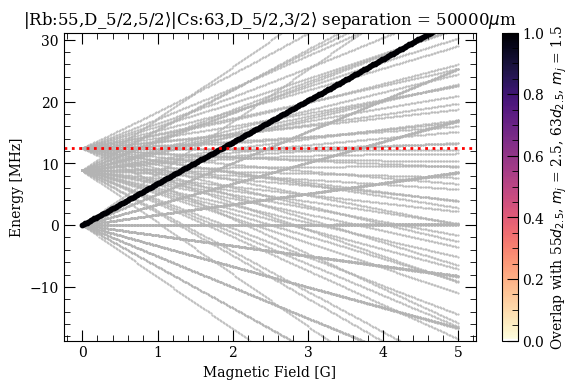

NameError: name 'path' is not defined

In [18]:


for i, d in enumerate(r):
    fig, ax = plt.subplots(ncols=1, figsize=(6, 4))
    ax.set_xlabel("E_z (mV/cm)")
    ax.set_ylabel(f"Energy ({energy_unit})")
    ax.set_title(fr'separation {d} $\mu$m')
    # ax.set_ylim(-0.01, 0.01)

    # system_atom = system_atom_dict[efield]
    pair_energy = ket1_energy + ket2_energy
    system_pairs = system_pairs_dict[d]


    energies = [system.get_eigenenergies(unit = energy_unit) - pair_energy for system in system_pairs]    
    overlaps = [system.get_eigenbasis().get_overlaps([ket1, ket2]) for system in system_pairs]

    # ax.plot(e_fields_sub, energies)
    for x, es in zip(b_fields_sub, energies):
        plt.plot([x] * len(es), es, c='.7', ls="None", marker=".", ms=1, zorder=-1)

    plt.axhline(defect, color='r', linewidth=2, alpha=1, linestyle='dotted')

    plt.tight_layout()
    plt.title(fr'{str(ket1)}{str(ket2)} separation = {d}$\mu$m')
    
    energy_lim = abs(defect + defect)
    offset=defect/2
    min_energy = -energy_lim+offset
    max_energy = energy_lim+offset
    plt.ylim(min_energy, max_energy)
    # plt.xlim(2, 2.7)
    plt.ylabel(f"Energy [{energy_unit}]")
    plt.xlabel("Magnetic Field [G]")

    min_overlap = 0.000
    for x, es, os in zip(b_fields_sub, energies, overlaps):
        inds = np.argwhere(os > min_overlap).flatten()
        inds = inds[np.argsort(os[inds])]
        if len(inds) > 0:
            scat = plt.scatter(
                [x] * len(es[inds]),
                es[inds],
                c=os[inds],
                s=10,
                vmin=0,
                vmax=1,
                cmap=alphamagma,
            )
    fig.colorbar(scat, ax=ax, label=fr"Overlap with {ket1.n}${orbs[int(ket1.l)]}_{{{ket1.j}}}$, $m_j$ = {ket1.m}, {ket2.n}${orbs[int(ket2.l)]}_{{{ket2.j}}}$, $m_j$ = {ket2.m}")
    # plt.hlines((defect), xmin=magnetic_fields[0], xmax=magnetic_fields[-1], color='red', linestyle='dashed')
    plt.show()
    fig.savefig(path + f'level pairstate sep{r}.png')